## **Import Libraries**

In [ ]:
import tensorflow

In [ ]:
import os
import re
import cv2
import time
import tarfile
import datetime
import warnings
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow import concat
from tensorflow import repeat
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
warnings.filterwarnings('ignore')
from sklearn.utils import shuffle
from skimage.transform import resize
import nltk.translate.bleu_score as bleu
from tensorflow.keras.models import Model
from google.colab.patches import cv2_imshow
from tensorflow.keras.models import load_model
from tensorflow.keras.backend import expand_dims 
from nltk.translate.bleu_score import sentence_bleu
from tensorflow.keras.layers import TimeDistributed
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import concatenate, Concatenate
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import Input, Softmax, RNN, Dense, Embedding, LSTM, Layer, Dropout, GRU

## **EDA,Preprocessing,structured data**

### Unzip all files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cwd = os.getcwd()

In [ ]:
images = tarfile.open('/content/drive/MyDrive/Project - XML/NLMCXR_png.tgz')
images.extractall(cwd+'/images/')

In [ ]:
xml = tarfile.open('/content/drive/MyDrive/Project - XML/NLMCXR_reports.tgz')
xml.extractall(cwd+'/reports/')

#### Sample-file

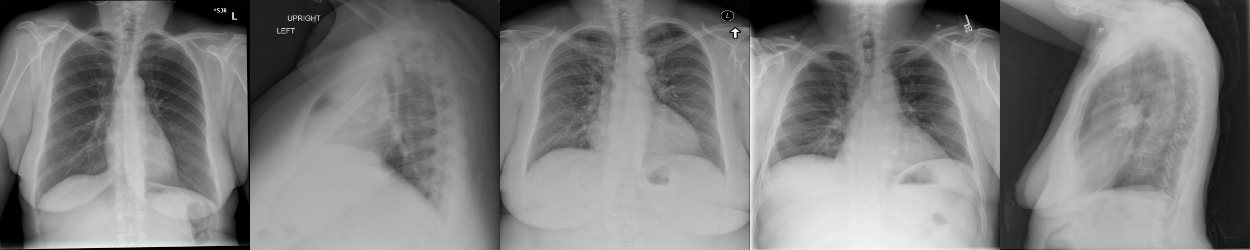

In [ ]:
# Displaying Random Images

img_list = []
for i in range(0,5):
  k = np.random.choice(range(len(os.listdir('/content/images'))))
  image_file = os.listdir('/content/images')[k]
  img = cv2.imread(os.path.join('/content/images',image_file))
  img = cv2.resize(img,(250,250))
  img_list.append(img)
img_list = np.hstack(img_list)
cv2_imshow(img_list)

In [ ]:
# Display an XML file

with open('/content/reports/ecgen-radiology/1.xml', 'r') as f:
  print(f.read())

<?xml version="1.0" encoding="utf-8"?>
<eCitation>
   <meta type="rr"/>
   <uId id="CXR1"/>
   <pmcId id="1"/>
   <docSource>CXR</docSource>
   <IUXRId id="1"/>
   <licenseType>open-access</licenseType>
   <licenseURL>http://creativecommons.org/licenses/by-nc-nd/4.0/</licenseURL>
   <ccLicense>byncnd</ccLicense>
   <articleURL/>
   <articleDate>2013-08-01</articleDate>
   <articleType>XR</articleType>
   <publisher>Indiana University</publisher>
   <title>Indiana University Chest X-ray Collection</title>
   <note>The data are drawn from multiple hospital systems.</note>
   <specialty>pulmonary diseases</specialty>
   <subset>CXR</subset>
   <MedlineCitation Owner="Indiana University" Status="supplied by publisher">
   
      <Article PubModel="Electronic">
      
         <Journal>
         
            <JournalIssue>
            
               <PubDate>
               
                  <Year>2013</Year>
               
                  <Month>08</Month>
               
            

In [ ]:
# Checking data stats

print('Total Images in data : ',len(os.listdir('/content/images')))
print('Total Reports in data : ',len(os.listdir('/content/reports/ecgen-radiology')))

Total Images in data :  7471
Total Reports in data :  3955


Observations :
There are 7471 images and 3955 reports in dataset.
Few Reports have more than image assoicated with them.

In [ ]:
# list of count of images

img_count = []

for file in os.listdir('/content/reports/ecgen-radiology'):
  xml_file = os.path.join('/content/reports/ecgen-radiology',file)
  # reading the xml data
  with open(xml_file,'r') as f:
    data = f.read()
  # getting all the image names
  regex = r"parentImage id.*"
  k = re.findall(regex,data)
  temp = len(k)
  img_count.append(temp)

print("The max number of images associated with a report:",np.array(img_count).max())
print("The min number of images associated with a report:",np.array(img_count).min())

The max number of images associated with a report: 5
The min number of images associated with a report: 0


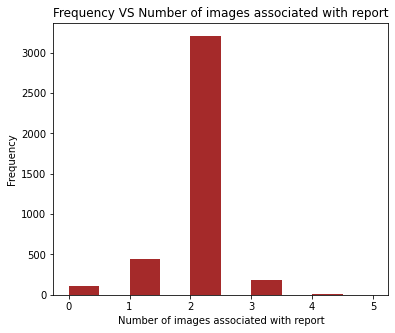

In [ ]:
plt.figure(figsize = (6,5))
ax = pd.Series(img_count).plot(kind='hist',color='brown')
ax.set_xlabel('Number of images associated with report')
ax.set_title("Frequency VS Number of images associated with report")
plt.show()

In [ ]:
print("Images per patient :\n")
print(pd.Series(img_count).value_counts())

Images per patient :

2    3208
1     446
3     181
0     104
4      15
5       1
dtype: int64


Observation :

We can see that the maximum number of images associated with a report can be 5 while the minimum is 0. The highest frequecy of being associated with a report are 2 images.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### **Dataset Preparation**

In [ ]:
from tqdm import tqdm
import xml.etree.ElementTree as ET

In [ ]:
# Reports are in xml format . we need to xml parsing.

# input features : Images and we will also take abstract,comparison,indication,finding as text input features.
# target variable : Impression (Text Feature)

columns = ["image_name", "image_caption", "comparison", "indication", "findings", "impression"]
dataframe = pd.DataFrame(columns = columns)
for file in tqdm(os.listdir('/content/reports/ecgen-radiology/')):
    #find files with .xml extension only
    if file.endswith(".xml"):
        # finding root element 
        tree = ET.parse('/content/reports/ecgen-radiology/'+file)#parse the xml file
        
        findings = tree.find(".//AbstractText[@Label='FINDINGS']").text
        indication = tree.find(".//AbstractText[@Label='INDICATION']").text
        comparision = tree.find(".//AbstractText[@Label='COMPARISON']").text
        impression = tree.find(".//AbstractText[@Label='IMPRESSION']").text

        caption = set()
        name_img = set()
        #find images in each parentImage tag
        for iterator in tree.findall("parentImage"):
            img = iterator.attrib['id']+".png"
            name_img.add(img)
            #add the corresponding report for each image
            caption.add('' if iterator.find('caption').text is None else iterator.find('caption').text)
            
        # add image details and reports to dataframe
        dataframe = dataframe.append(pd.Series([','.join(name_img), ','.join(caption), comparision, indication, findings, impression],
                                                         index = columns), ignore_index = True)

100%|██████████| 3955/3955 [00:12<00:00, 327.06it/s]


In [ ]:
dataframe.head()

,image_name,image_caption,comparison,indication,findings,impression
0,"CXR3948_IM-2017-1002.png,CXR3948_IM-2017-1001.png",PA and lateral chest x-XXXX XXXX.,XXXX.,"XXXX-year-old male, XXXX.",The cardiomediastinal silhouette is within nor...,No acute cardiopulmonary process.
1,"CXR3632_IM-1799-1001.png,CXR3632_IM-1799-2001.png","PA and Lateral Chest. XXXXth, XXXX XXXX hours",Chest x-XXXX XXXX,"XXXX-year-old male, XXXX",Normal heart size and mediastinal contours. Ca...,1. Small left pleural effusion.
2,"CXR2713_IM-1180-1001.png,CXR2713_IM-1180-2001.png",PA and lateral views of chest performed XXXX/X...,Two-view chest XXXX.,XXXX-year-old with a XXXX.,The heart is normal in size and contour. The a...,1. Low lung volume study with minimal bibasila...
3,"CXR2361_IM-0926-1002.png,CXR2361_IM-0926-1001.png",PA and lateral views of the chest.,PA and lateral views of the chest from XXXX.,XXXX year old female with XXXX for 3 years.,Stable mild rightward curvature of the thoraci...,No acute cardiopulmonary findings.
4,"CXR573_IM-2171-3001.png,CXR573_IM-2171-4004.pn...",Xray Chest PA and Lateral,"XXXX XXXX, chest x-XXXX XXXX",Dyspnea.,The XXXX examination consists of frontal and l...,No evidence of acute cardiopulmonary disease o...


In [ ]:
print('Shape of the dataframe :',dataframe.shape)

Shape of the dataframe : (3955, 6)


#### **Preprocessing**

In [ ]:
# function for obtaining the different information part of the xml report file and preprocessing them and also adding the concernced image and report information to the dataframe
def decontracted(phrase): #https://stackoverflow.com/a/47091490
  """
  performs text decontraction of words like won't to will not
  """
  # specific
  phrase = re.sub(r"won\'t", "will not", phrase)
  phrase = re.sub(r"can\'t", "can not", phrase)

  # general
  phrase = re.sub(r"n\'t", " not", phrase)
  phrase = re.sub(r"\'re", " are", phrase)
  phrase = re.sub(r"\'s", " is", phrase)
  phrase = re.sub(r"\'d", " would", phrase)
  phrase = re.sub(r"\'ll", " will", phrase)
  phrase = re.sub(r"\'t", " not", phrase)
  phrase = re.sub(r"\'ve", " have", phrase)
  phrase = re.sub(r"\'m", " am", phrase)
  return phrase

In [ ]:
from bs4 import BeautifulSoup

In [ ]:
def preprocess_text(data): #https://regex101.com/
  """
  extracts the information data from the xml file and does text preprocessing on them
  here info can be 1 value in this list ["COMPARISON","INDICATION","FINDINGS","IMPRESSION"]
  """
  preprocessed = []

  for sentence in tqdm(data.values):

    sentence = BeautifulSoup(sentence, 'lxml').get_text()

    regex = r"\d." 
    sentence = re.sub(regex,"",sentence) #removing all values like "1." and "2." etc

    regex = r"X+"
    sentence = re.sub(regex,"",sentence) #removing words like XXXX

    regex = r"[^.a-zA-Z]" 
    sentence = re.sub(regex," ",sentence) #removing all special characters except for full stop

    regex = r"http\S+"
    sentence = re.sub(regex,"", sentence)
    sentence = re.sub(r"[-()\"#/@;:<>{}`+=~|.!?$%^&*'/+\[\]_]+", "", sentence)
    sentence = re.sub('&', 'and',sentence)
    sentence = re.sub('@', 'at',sentence)
    sentence = re.sub('0', 'zero',sentence)
    sentence = re.sub('1', 'one',sentence)
    sentence = re.sub('2', 'two',sentence)
    sentence = re.sub('3', 'three',sentence)
    sentence = re.sub('4', 'four',sentence)
    sentence = re.sub('5', 'five',sentence)
    sentence = re.sub('6', 'six',sentence)
    sentence = re.sub('7', 'seven',sentence)
    sentence = re.sub('8', 'eight',sentence)
    sentence = re.sub('9', 'nine',sentence)
    sentence = re.sub('year old', "", sentence)#Occur multiple times in Indication feature but not necessary     
    sentence = re.sub('yearold', "", sentence)
    sentence = decontracted(sentence) #perform decontraction
    sentence = sentence.strip().lower() #strips the begining and end of the string of spaces and converts all into lowercase
    sentence = " ".join(sentence.split()) #removes unwanted spaces
    if sentence=="": #if the resulting sentence is an empty string return null value
      sentence = np.nan
    preprocessed.append(sentence)
  return preprocessed

In [ ]:
#Check for Null values in Text columns
NaN = dataframe.isnull().sum()
print("Total Nan Values in caption columns -",NaN[1])
print("Total Nan Values in comparison columns -",NaN[2])
print("Total Nan Values in Indication columns -",NaN[3])
print("Total Nan Values in findings columns   -",NaN[4])
print("Total Nan Values in Impression columns -",NaN[5])

Total Nan Values in caption columns - 0
Total Nan Values in comparison columns - 622
Total Nan Values in Indication columns - 90
Total Nan Values in findings columns   - 530
Total Nan Values in Impression columns - 34


In [ ]:
#Replacing the nan values
dataframe['image_caption'] = dataframe['image_caption'].fillna('Unknown')
dataframe['comparison'] = dataframe['comparison'].fillna('No Comparison')
dataframe['indication'] = dataframe['indication'].fillna('No Indication')
dataframe['findings'] = dataframe['findings'].fillna('No Findings')
dataframe['impression'] = dataframe['impression'].fillna('No Impression')


In [ ]:
NaN = dataframe.isnull().sum()
print("Total Nan Values in caption columns -",NaN[1])
print("Total Nan Values in comparison columns -",NaN[2])
print("Total Nan Values in Indication columns -",NaN[3])
print("Total Nan Values in findings columns   -",NaN[4])
print("Total Nan Values in Impression columns -",NaN[5])

Total Nan Values in caption columns - 0
Total Nan Values in comparison columns - 0
Total Nan Values in Indication columns - 0
Total Nan Values in findings columns   - 0
Total Nan Values in Impression columns - 0


In [ ]:
#Preprocessing of text features
dataframe['image_caption'] = preprocess_text(dataframe['image_caption'])
dataframe['comparison'] = preprocess_text(dataframe['comparison'])
dataframe['indication'] = preprocess_text(dataframe['indication'])
dataframe['findings'] = preprocess_text(dataframe['findings'])
dataframe['impression'] = preprocess_text(dataframe['impression'])

100%|██████████| 3955/3955 [00:01<00:00, 3484.79it/s]


In [ ]:
dataframe.head()

,image_name,image_caption,comparison,indication,findings,impression
0,"CXR3948_IM-2017-1002.png,CXR3948_IM-2017-1001.png",pa and lateral chest x,NaN,male,the cardiomediastinal silhouette is within nor...,no acute cardiopulmonary process
1,"CXR3632_IM-1799-1001.png,CXR3632_IM-1799-2001.png",pa and lateral chest th hours,chest x,male,normal heart size and mediastinal contours cal...,small left pleural effusion
2,"CXR2713_IM-1180-1001.png,CXR2713_IM-1180-2001.png",pa and lateral views of chest performed at,two view chest,with a,the heart is normal in size and contour the ao...,low lung volume study with minimal bibasilar a...
3,"CXR2361_IM-0926-1002.png,CXR2361_IM-0926-1001.png",pa and lateral views of the chest,pa and lateral views of the chest from,female with for years,stable mild rightward curvature of the thoraci...,no acute cardiopulmonary findings
4,"CXR573_IM-2171-3001.png,CXR573_IM-2171-4004.pn...",ray chest pa and lateral,chest x,dyspnea,the examination consists of frontal and latera...,no evidence of acute cardiopulmonary disease o...


Observation :

I did some text preprocessing in XML, for four labels (comparision,indcation, impression and findings). I analyze the text data, then perform tasks like decontraction (can't ---> can not), remove special character, convert in lowercase.

I have also preprocessed Image caption feature, For getting additional information about the corrosponding image.

Missing values are also present in image_name feature. As at some place nothing is assigned on image_name.

In [ ]:
dataframe.replace("",float("NaN"),inplace=True)

In [ ]:
# Percentage missing value 
print(dataframe.isnull().sum()*100/dataframe.shape[0])

image_name        2.629583
image_caption     2.680152
comparison       20.960809
indication        5.638432
findings          0.025284
impression        0.000000
dtype: float64


Observation : We can see that there are still missing values in the data. We could remove all rows where image_name are null since they represent below 3% of the total datapoints.

In [ ]:
dataframe.dropna(subset=["image_name"],inplace=True)
dataframe.shape

(3851, 6)

In [ ]:
dataframe.head()

,image_name,image_caption,comparison,indication,findings,impression
0,"CXR3948_IM-2017-1002.png,CXR3948_IM-2017-1001.png",pa and lateral chest x,NaN,male,the cardiomediastinal silhouette is within nor...,no acute cardiopulmonary process
1,"CXR3632_IM-1799-1001.png,CXR3632_IM-1799-2001.png",pa and lateral chest th hours,chest x,male,normal heart size and mediastinal contours cal...,small left pleural effusion
2,"CXR2713_IM-1180-1001.png,CXR2713_IM-1180-2001.png",pa and lateral views of chest performed at,two view chest,with a,the heart is normal in size and contour the ao...,low lung volume study with minimal bibasilar a...
3,"CXR2361_IM-0926-1002.png,CXR2361_IM-0926-1001.png",pa and lateral views of the chest,pa and lateral views of the chest from,female with for years,stable mild rightward curvature of the thoraci...,no acute cardiopulmonary findings
4,"CXR573_IM-2171-3001.png,CXR573_IM-2171-4004.pn...",ray chest pa and lateral,chest x,dyspnea,the examination consists of frontal and latera...,no evidence of acute cardiopulmonary disease o...


In [ ]:
# Add image count as feature
dataframe['image_count'] = dataframe['image_name'].astype(str).str.split(',').apply(len)

In [ ]:
#Adding word count feature for indication, findings and impression
dataframe['indication_count'] = dataframe['indication'].astype(str).str.split().apply(lambda x: 0 if x==None else len(x))
dataframe['findings_count'] = dataframe['findings'].astype(str).str.split().apply(lambda x: 0 if x==None else len(x))
dataframe['impression_count'] = dataframe['impression'].astype(str).str.split().apply(lambda x: 0 if x==None else len(x))
dataframe.head()

,image_name,image_caption,comparison,indication,findings,impression,image_count,indication_count,findings_count,impression_count
0,"CXR3948_IM-2017-1002.png,CXR3948_IM-2017-1001.png",pa and lateral chest x,NaN,male,the cardiomediastinal silhouette is within nor...,no acute cardiopulmonary process,2,1,30,4
1,"CXR3632_IM-1799-1001.png,CXR3632_IM-1799-2001.png",pa and lateral chest th hours,chest x,male,normal heart size and mediastinal contours cal...,small left pleural effusion,2,1,34,4
2,"CXR2713_IM-1180-1001.png,CXR2713_IM-1180-2001.png",pa and lateral views of chest performed at,two view chest,with a,the heart is normal in size and contour the ao...,low lung volume study with minimal bibasilar a...,2,2,40,10
3,"CXR2361_IM-0926-1002.png,CXR2361_IM-0926-1001.png",pa and lateral views of the chest,pa and lateral views of the chest from,female with for years,stable mild rightward curvature of the thoraci...,no acute cardiopulmonary findings,2,4,25,4
4,"CXR573_IM-2171-3001.png,CXR573_IM-2171-4004.pn...",ray chest pa and lateral,chest x,dyspnea,the examination consists of frontal and latera...,no evidence of acute cardiopulmonary disease o...,3,1,50,10


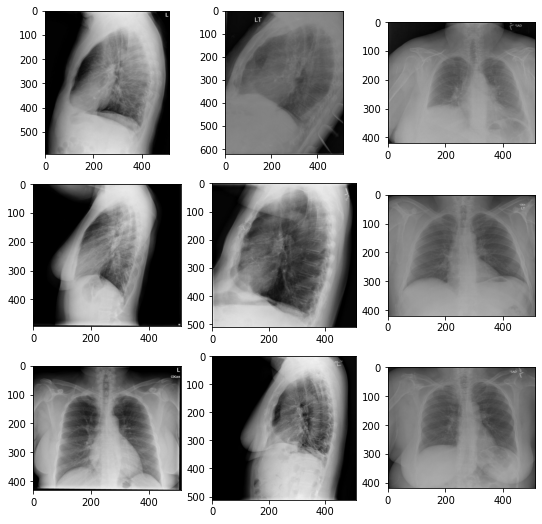

In [ ]:
#Displaying sample 9 patient X-Ray
fig, axs = plt.subplots(3, 3, figsize = (9,9))
ax = axs.flatten()
for df, figure in zip(dataframe[0:10].itertuples(), ax):
    image=mpimg.imread("/content/images/"+df.image_name.split(',')[0])
    figure.imshow(image)
plt.show()

In [ ]:
def show_image_captions(df,sample):
    '''This function prints the sample images and its other text features.
       Parameters :
       - df: dataframe
       - sample: Number of datapoints'''
    
    sampled_row = df.sample(sample)

    for count, row in sampled_row.iterrows():
        print("Caption :",row['image_caption'])
        imgs = row["image_name"].split(',')
        fig, axs = plt.subplots(1, len(imgs), figsize = (10,10))
        iterator = 0

        for img, figure in zip(imgs, axs.flat):
            image= mpimg.imread("/content/images/"+img)
            imgplot = axs[iterator].imshow(image)
            iterator +=1
        
        plt.show()
        print("\nComparision :",row.get('comparision'))
        print("\nIndication :",row.get('indication'))
        print("\nFindings :",row.get('findings'))
        print("\nImpression :",row.get('impression'))
        print("="*100,'\n')


Caption : pa and lateral chest


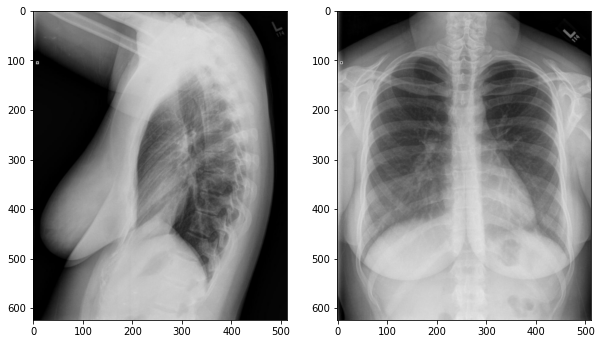


Comparision : None

Indication : female with for one

Findings : the lungs are clear heart size and mediastinal contours are normal no osseous abnormalities

Impression : no impression

Caption : ray chest pa and lateral


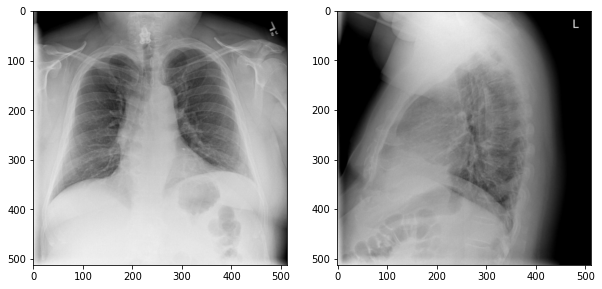


Comparision : None

Indication : chest pain for weeks pain anteriorly over the lower right chest

Findings : the heart pulmonary and mediastinum are within normal limits there is no pleural effusion or pneumothorax there is no focal air space opacity to suggest a pneumonia there is mild biapical pleural thickening which is smooth there is evidence of previous anterior cervical spine fusion there are degenerative changes of the spine

Impression : no acute cardiopulmonary disease



In [ ]:
#showing sample 2 datapoints
show_image_captions(dataframe, 2)

In [ ]:
dataframe.to_csv('/content/drive/MyDrive/Project_CSVs/data.csv',index = False)